In [1]:
# 1. Import and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer,
    roc_auc_score, precision_recall_curve, auc
)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

from sklearn.feature_selection import SelectKBest, f_classif, RFE
from tqdm import tqdm

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# 2. Load Data
path = "diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(
    path,
    engine="python",          # parser Python lebih fleksibel untuk CSV 'kotor'
    on_bad_lines="skip",      # skip baris yang kolomnya tidak pas
)
print(df.shape)

df.head(20)

(253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

Deskripsi Fitur Dataset – Prediksi Diabetes

# 1. Diabetes_012

0 = Tidak diabetes

1 = Prediabetes

2 = Diabetes

# 2. HighBP

0 = Tidak memiliki tekanan darah tinggi

1 = Memiliki tekanan darah tinggi

# 3. HighChol

0 = Tidak memiliki kolesterol tinggi

1 = Memiliki kolesterol tinggi

# 4. CholCheck

0 = Tidak pernah melakukan tes kolesterol dalam 5 tahun terakhir

1 = Pernah melakukan tes kolesterol dalam 5 tahun terakhir

# 5. BMI (Body Mass Index / Indeks Massa Tubuh) – nilai numerik

# 6. Smoker

0 = Tidak pernah merokok setidaknya 100 batang sepanjang hidup

1 = Pernah merokok setidaknya 100 batang sepanjang hidup
(Catatan: 5 bungkus = 100 batang)

# 7. Stroke

0 = Tidak pernah didiagnosis stroke

1 = Pernah didiagnosis stroke

# 8. HeartDiseaseorAttack

0 = Tidak pernah didiagnosis penyakit jantung koroner atau serangan jantung (CHD/MI)

1 = Pernah didiagnosis CHD/MI

# 9. PhysActivity

0 = Tidak melakukan aktivitas fisik dalam 30 hari terakhir (di luar pekerjaan)

1 = Melakukan aktivitas fisik dalam 30 hari terakhir (di luar pekerjaan)

# 10. Fruits

0 = Mengonsumsi buah < 1 kali per hari

1 = Mengonsumsi buah ≥ 1 kali per hari

# 11. Veggies

0 = Mengonsumsi sayur < 1 kali per hari

1 = Mengonsumsi sayur ≥ 1 kali per hari

# 12. HvyAlcoholConsump

0 = Bukan peminum berat

1 = Peminum berat
(Definisi: Pria >14 gelas/minggu, Wanita >7 gelas/minggu)

# 13. AnyHealthcare

0 = Tidak memiliki asuransi atau jaminan kesehatan

1 = Memiliki asuransi atau jaminan kesehatan

# 14. NoDocbcCost

0 = Tidak pernah terkendala biaya untuk ke dokter dalam 12 bulan terakhir

1 = Pernah terkendala biaya untuk ke dokter dalam 12 bulan terakhir

# 15. GenHlth (Kesehatan secara umum) – Skala 1–5:
1 = Sangat baik sekali (Excellent)
2 = Sangat baik (Very good)
3 = Baik (Good)
4 = Cukup (Fair)
5 = Buruk (Poor)

# 16. MentHlth (Kesehatan mental) – Jumlah hari (1–30) dalam 30 hari terakhir kesehatan mental tidak baik (stres, depresi, masalah emosional).

# 17. PhysHlth (Kesehatan fisik) – Jumlah hari (1–30) dalam 30 hari terakhir kesehatan fisik tidak baik (penyakit atau cedera).

# 18. DiffWalk

0 = Tidak kesulitan berjalan atau naik tangga

1 = Kesulitan berjalan atau naik tangga

# 19. Sex

0 = Perempuan

1 = Laki-laki

# 20. Age (Kategori usia 13 level, _AGEG5YR):
1 = 18–24 tahun
9 = 60–64 tahun
13 = ≥ 80 tahun

# 21. Education (EDUCA, skala 1–6):
1 = Tidak pernah sekolah / hanya TK
2 = SD (kelas 1–8)
3 = SMP (kelas 9–11)
4 = SMA / GED
5 = Perguruan tinggi 1–3 tahun (diploma/teknik)
6 = Perguruan tinggi ≥4 tahun (sarjana)

# 22. Income (INCOME2, skala 1–8 dalam $):
* 1 =< 10.000
* 5 =< 35.000
* 8 ≥ 75.000

In [ ]:
# 3. Exploratory Data Analysis (EDA)
# label kelas untuk klasifikasi harus berupa bilangan bulat (0,1,2). jika tipe data menggunakan float, beberapa tools evaluasi akan menganggapnya numerik kontinu sehingga berisiko KeyError/mismatch label saat classification_report/confusion_matrix
df["Diabetes_012"] = pd.to_numeric(df["Diabetes_012"], errors="coerce").round().astype("Int64")

allowed = {0, 1, 2, pd.NA}
uni = set(df["Diabetes_012"].unique())
bad_vals = {v for v in uni if v not in allowed}
if bad_vals:
    print("warning: found data outside {0,1,2}:", bad_vals)
    df = df[df["Diabetes_012"].isin([0,1,2])]

# label kelas bertipe biner diubah menjadi integer agar dapat teridentifikasi/terpisah dari fitur kontinu yang akan berguna ketika melakukan balancing kelas menggunakan SMOTE
binary_cols = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke",
    "HeartDiseaseorAttack","PhysActivity","Fruits","Veggies",
    "HvyAlcoholConsump","AnyHealthcare","NoDocbcCost",
    "DiffWalk","Sex"
]

for c in binary_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").round().astype("Int64")

ordinal_cols = ["GenHlth", "Age", "Education", "Income"]
for c in ordinal_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").round().astype("Int64")

numeric_cols = ["MentHlth", "PhysHlth"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").round().astype("Int64")

# untuk fitur kontinu dibiarkan float (akan diskalakan nanti untuk Logistic Regression)

df.head(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [ ]:
print("Shape dataset:", df.shape)
print("\nDistribusi Target:")
print(df["Diabetes_012"].value_counts().sort_index())

Shape dataset: (253680, 22)

Distribusi Target:
Diabetes_012
0    213703
1      4631
2     35346
Name: count, dtype: Int64


In [ ]:
print("=== Statistik Deskriptif ===")
print(df.describe().T)

=== Statistik Deskriptif ===
                         count       mean       std   min   25%   50%   75%  \
Diabetes_012          253680.0   0.296921   0.69816   0.0   0.0   0.0   0.0   
HighBP                253680.0   0.429001  0.494934   0.0   0.0   0.0   1.0   
HighChol              253680.0   0.424121   0.49421   0.0   0.0   0.0   1.0   
CholCheck             253680.0    0.96267  0.189571   0.0   1.0   1.0   1.0   
BMI                   253680.0  28.382364  6.608694  12.0  24.0  27.0  31.0   
Smoker                253680.0   0.443169  0.496761   0.0   0.0   0.0   1.0   
Stroke                253680.0   0.040571  0.197294   0.0   0.0   0.0   0.0   
HeartDiseaseorAttack  253680.0   0.094186  0.292087   0.0   0.0   0.0   0.0   
PhysActivity          253680.0   0.756544  0.429169   0.0   1.0   1.0   1.0   
Fruits                253680.0   0.634256  0.481639   0.0   0.0   1.0   1.0   
Veggies               253680.0    0.81142  0.391175   0.0   1.0   1.0   1.0   
HvyAlcoholConsump     2

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/1203256930.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Diabetes_012", data=df, palette="viridis")


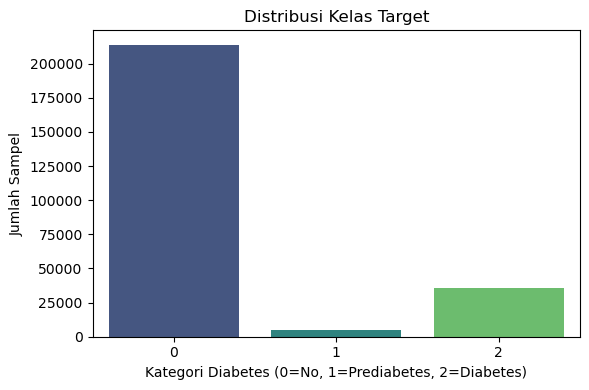

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Diabetes_012", data=df, palette="viridis")
plt.title("Distribusi Kelas Target")
plt.xlabel("Kategori Diabetes (0=No, 1=Prediabetes, 2=Diabetes)")
plt.ylabel("Jumlah Sampel")
plt.tight_layout()
plt.show()

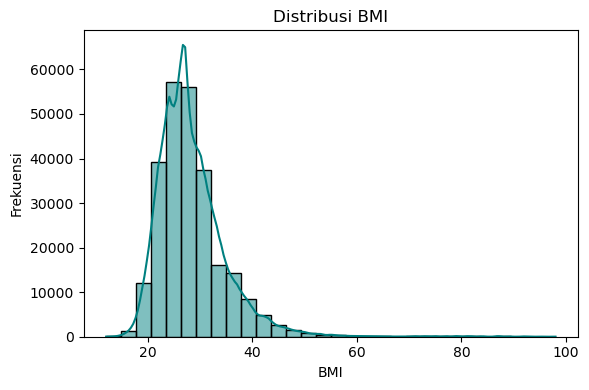

In [ ]:
continuous_features = ["BMI"]
for col in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color="teal")
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()


/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


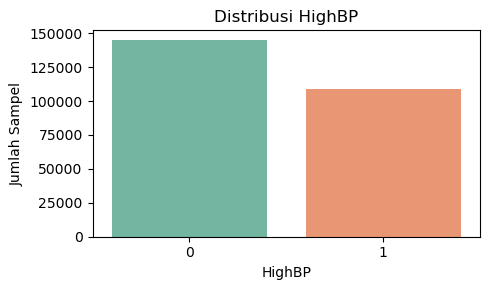

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


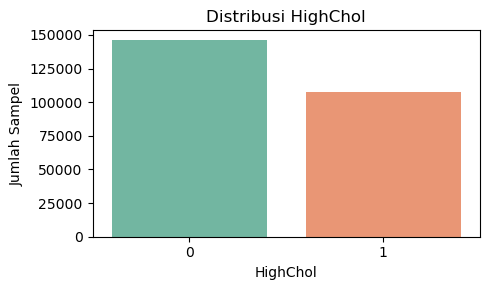

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


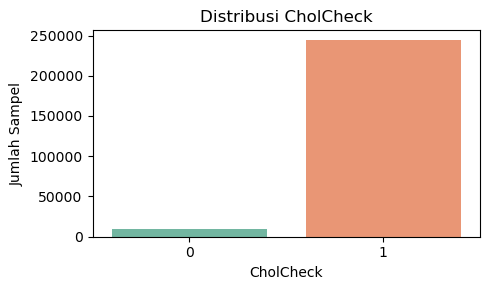

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


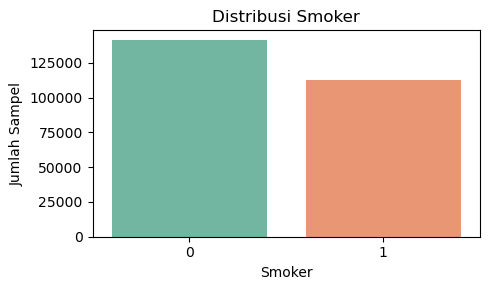

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


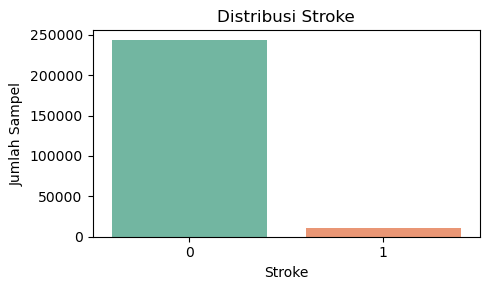

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


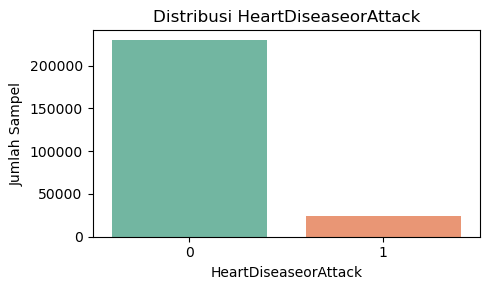

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


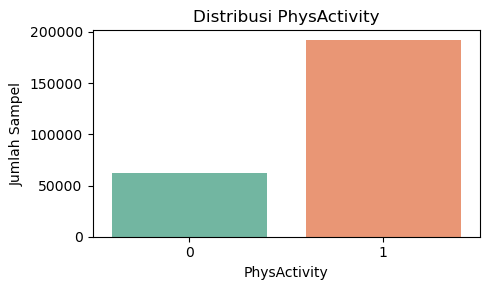

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


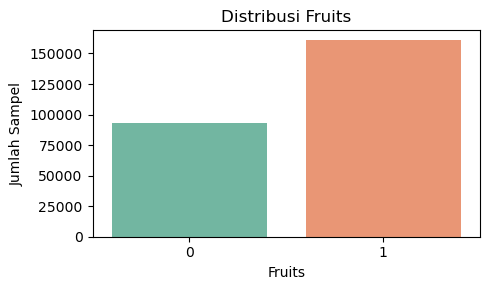

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


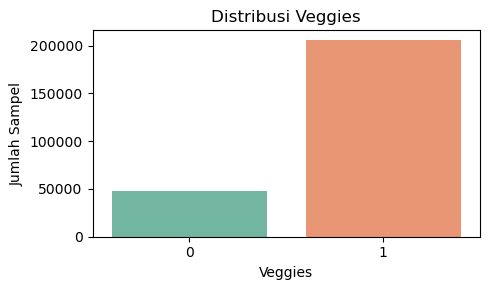

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


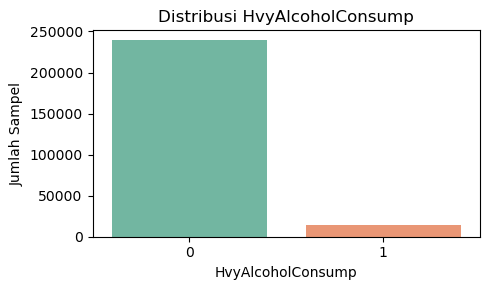

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


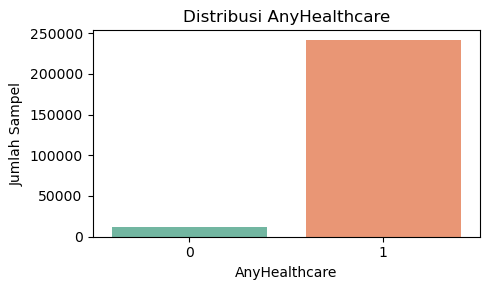

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


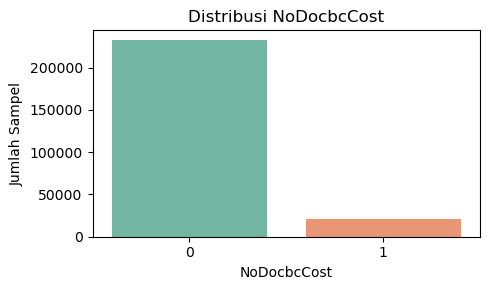

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


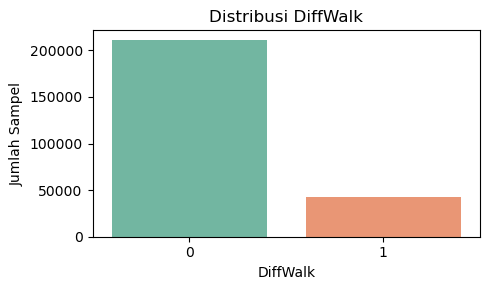

/var/folders/wx/2qhlnpq57d18msfzvkcs4qm00000gn/T/ipykernel_28238/2761480469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


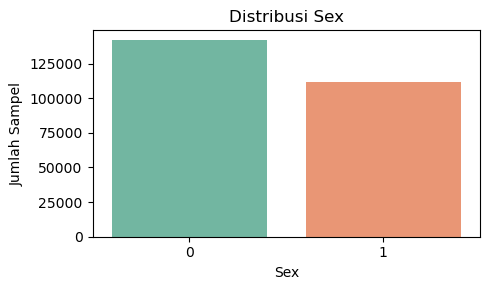

In [ ]:
binary_cols = ["HighBP","HighChol","CholCheck","Smoker","Stroke",
    "HeartDiseaseorAttack","PhysActivity","Fruits","Veggies",
    "HvyAlcoholConsump","AnyHealthcare","NoDocbcCost",
    "DiffWalk","Sex"]

for col in binary_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, data=df, palette="Set2")
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Jumlah Sampel")
    plt.tight_layout()
    plt.show()

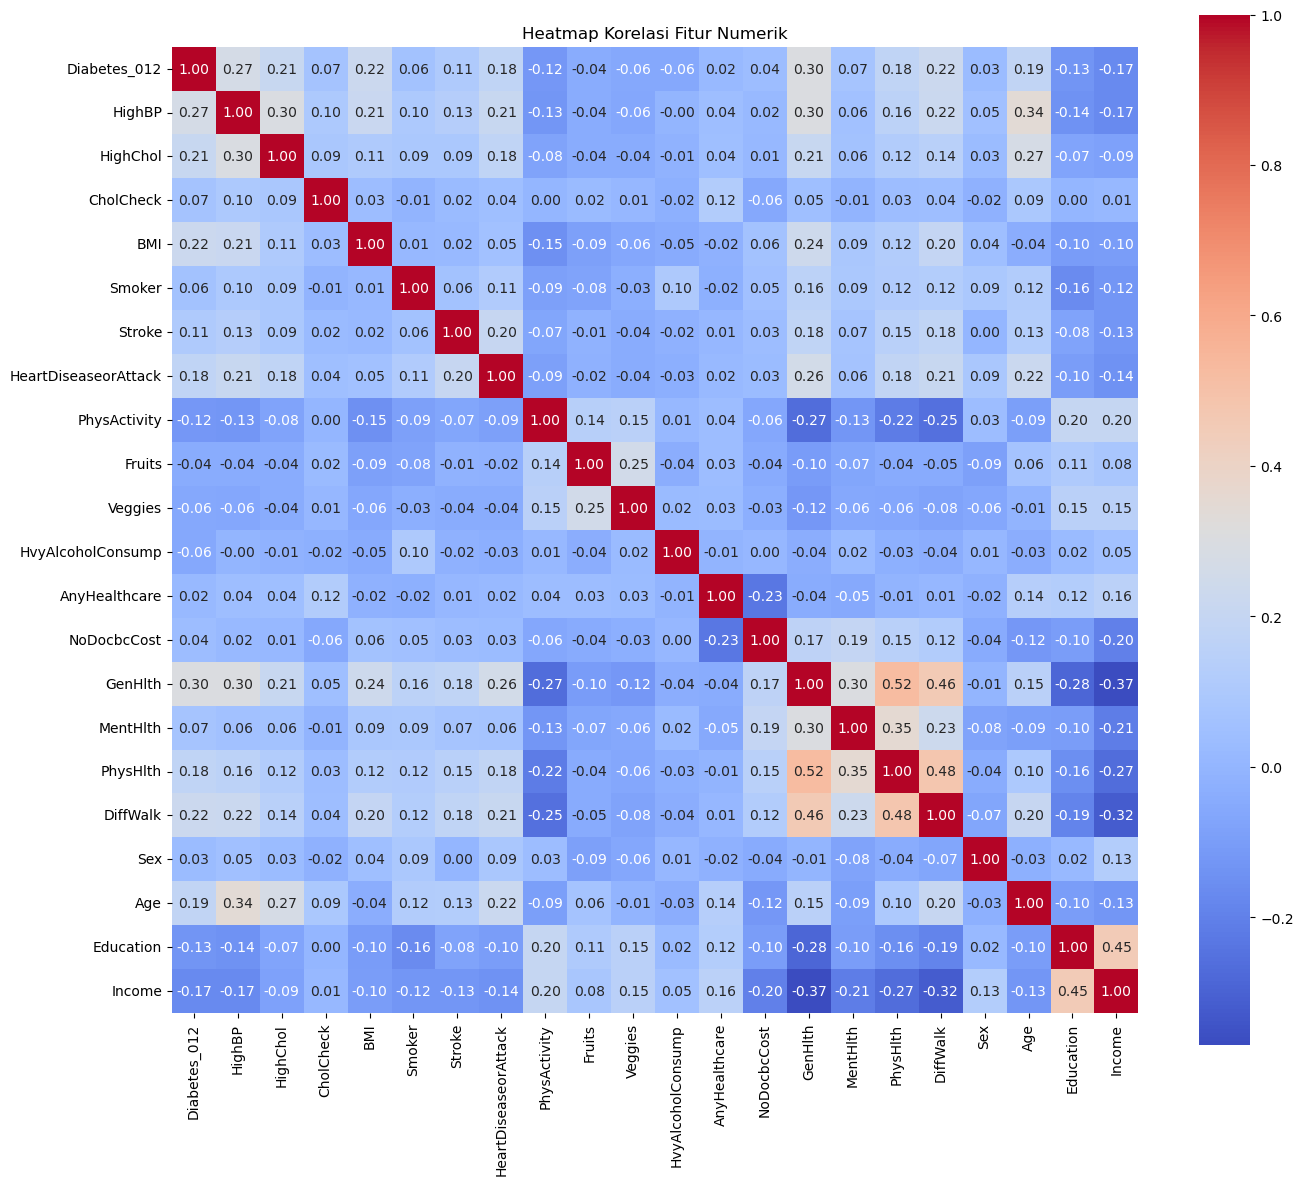

In [ ]:
plt.figure(figsize=(14, 12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

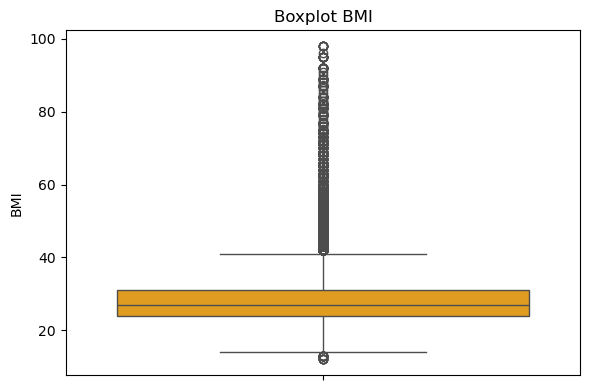

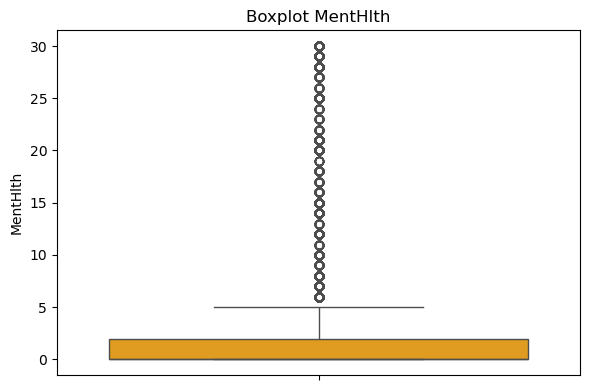

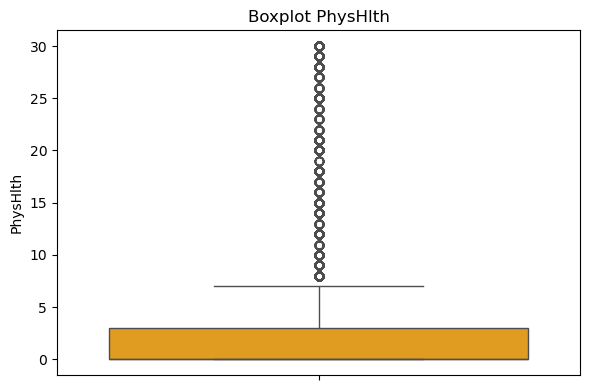

In [ ]:
for col in ["BMI", "MentHlth", "PhysHlth"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col], color="orange")
    plt.title(f"Boxplot {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
# 4. Preprocessing
# cek duplikasi data
dup_count = df.duplicated().sum()
print(f"Duplikasi baris: {dup_count}")

# drop duplikasi data
if dup_count > 0:
    df = df.drop_duplicates().copy()

dup_count = df.duplicated().sum()
print(f"Duplikasi baris: {dup_count}")

# cek missing value
na_cnt = df.isna().sum().sort_values(ascending=False)
na_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_report = (
    pd.DataFrame({"missing": na_cnt, "missing_%": na_pct})
      .query("missing > 0")
)
print("\n=== Missing Report (sebelum tindakan) ===")
print(missing_report if not missing_report.empty else "Tidak ada nilai hilang.")

Duplikasi baris: 23899
Duplikasi baris: 0

=== Missing Report (sebelum tindakan) ===
Tidak ada nilai hilang.


In [ ]:
imputer = SimpleImputer(strategy="median")
df[df.columns] = imputer.fit_transform(df)

In [ ]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

In [ ]:
for col in ["BMI", "MentHlth", "PhysHlth"]:
    df = remove_outliers_iqr(df, col)

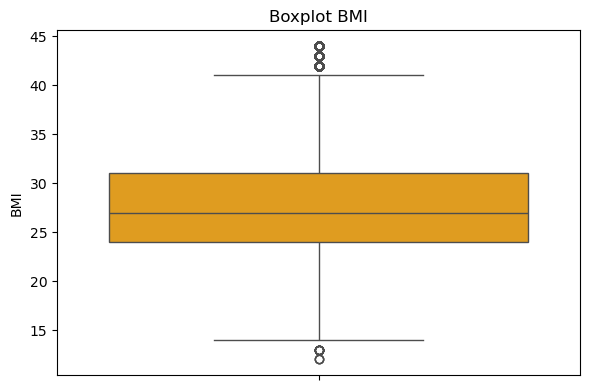

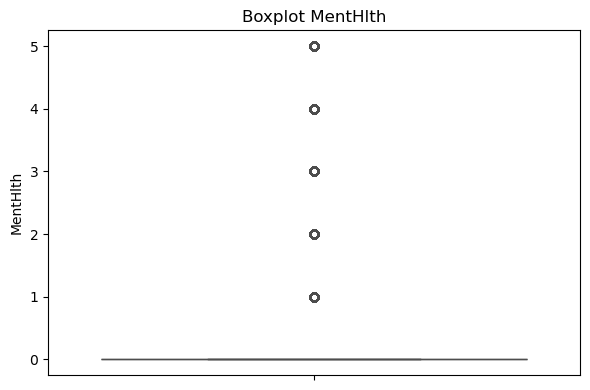

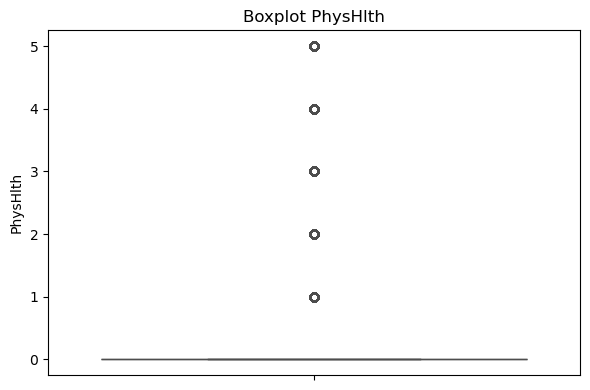

In [ ]:
for col in ["BMI", "MentHlth", "PhysHlth"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col], color="orange")
    plt.title(f"Boxplot {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
# berbeda dengan Logistic Regression, Random Forest tidak butuh scaling/normalisasi, karena pembentukan tree berdasarkan pemisahan nilai (threshold), bukan bobot/koefisien.

In [ ]:
# separate feature and column
target_cols = "Diabetes_012"

feature_cols = [c for c in df.columns if c != target_cols]
X = df[feature_cols].copy()
y = df[target_cols].copy()

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Ukuran data:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

Ukuran data:
X_train: (112770, 21) X_test: (48330, 21)


Distribusi Target (jumlah):
Diabetes_012
0.0    138131
1.0      2870
2.0     20099
Name: count, dtype: int64

Distribusi Target (%):
Diabetes_012
0.0    85.74%
1.0     1.78%
2.0    12.48%
Name: proportion, dtype: object


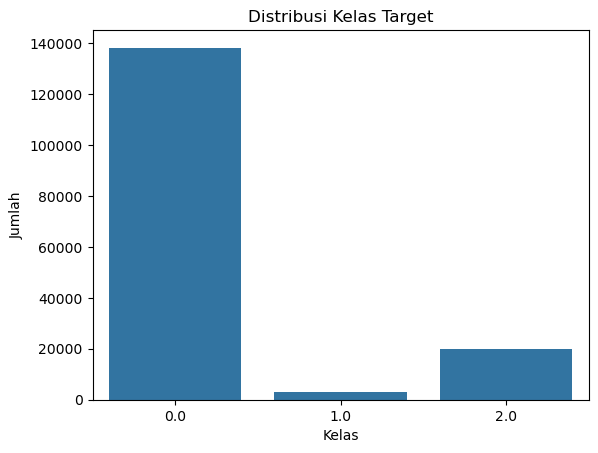

In [ ]:
# 5. cek balance dataset
print("Distribusi Target (jumlah):")
print(y.value_counts().sort_index())

print("\nDistribusi Target (%):")
print(y.value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")

sns.countplot(x=y)
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

In [ ]:
# 6. handling imbalance dataset
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribusi sebelum SMOTE:", y_train.value_counts())
print("Distribusi sesudah SMOTE:", y_train_res.value_counts())

Distribusi sebelum SMOTE: Diabetes_012
0.0    96692
2.0    14069
1.0     2009
Name: count, dtype: int64
Distribusi sesudah SMOTE: Diabetes_012
0.0    96692
2.0    96692
1.0    96692
Name: count, dtype: int64


In [ ]:
# data hasil SMOTE
X_fs = X_train_res
y_fs = y_train_res

In [ ]:
# 7. Feature Selection
# # save AUC result
results = {
    "SelectKBest": [],
    "RFE": [],
    "RF Importance": []
}

k_values_dict = {
    "SelectKBest": [],
    "RFE": [],
    "RF Importance": []
}

In [ ]:
# range jumlah feature
k_values = range(1, X_fs.shape[1] + 1)

# feature selection method 1 : SelectKBest (f_classif)
for k in tqdm(k_values, desc="SelectKBest"):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_new = selector.fit_transform(X_fs, y_fs)
    scores = cross_val_score(RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1), X_new, y_fs, cv=3, scoring="roc_auc_ovr")
    results["SelectKBest"].append(scores.mean())
    k_values_dict["SelectKBest"].append(k)

SelectKBest: 100%|██████████| 21/21 [02:19<00:00,  6.65s/it]


In [ ]:
# feature selection method 2 : Recursive Feature Elimination (RFE)
rf = RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1)
for k in tqdm(k_values, desc="RFE"):
    rfe = RFE(estimator=rf, n_features_to_select=k)
    X_new = rfe.fit_transform(X_fs, y_fs)
    scores = cross_val_score(rf, X_new, y_fs, cv=3, scoring="roc_auc_ovr")
    results["RFE"].append(scores.mean())
    k_values_dict["RFE"].append(k)

RFE: 100%|██████████| 21/21 [17:18<00:00, 49.44s/it]


In [ ]:
# feature selection method 3 : RF Feature Importance
rf.fit(X_fs, y_fs)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for k in tqdm(k_values, desc="RF Importance"):
    selected_idx = indices[:k]
    X_new = X_fs.iloc[:, selected_idx]
    scores = cross_val_score(RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1), X_new, y_fs, cv=3, scoring="roc_auc_ovr")
    results["RF Importance"].append(scores.mean())
    k_values_dict["RF Importance"].append(k)

RF Importance: 100%|██████████| 21/21 [02:34<00:00,  7.38s/it]


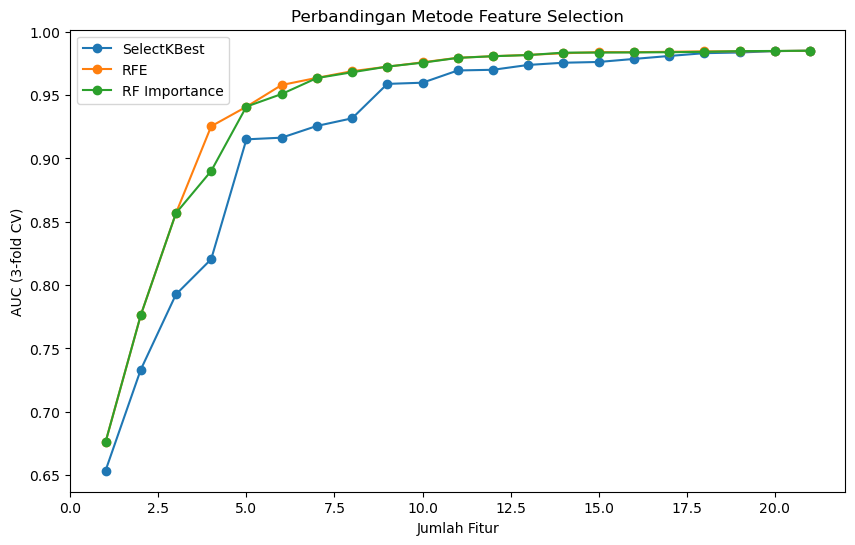

In [ ]:
# result
plt.figure(figsize=(10, 6))
for method, scores in results.items():
    plt.plot(k_values_dict[method], scores, marker="o", label=method)

plt.xlabel("Jumlah Fitur")
plt.ylabel("AUC (3-fold CV)")
plt.title("Perbandingan Metode Feature Selection")
plt.legend()
plt.show()

In [ ]:
k_optimal = 8

# --- 1. SelectKBest ---
selector = SelectKBest(score_func=f_classif, k=k_optimal)
selector.fit(X_fs, y_fs)
selected_features_kbest = X_fs.columns[selector.get_support()]
print("Fitur terpilih SelectKBest:", list(selected_features_kbest))


# --- 2. RFE ---
rf = RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1)
rfe = RFE(estimator=rf, n_features_to_select=k_optimal)
rfe.fit(X_fs, y_fs)
selected_features_rfe = X_fs.columns[rfe.get_support()]
print("Fitur terpilih RFE:", list(selected_features_rfe))


# --- 3. RF Feature Importance ---
rf.fit(X_fs, y_fs)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:k_optimal]
selected_features_rfimp = X_fs.columns[indices]
print("Fitur terpilih RF Importance:", list(selected_features_rfimp))

Fitur terpilih SelectKBest: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HeartDiseaseorAttack', 'GenHlth', 'DiffWalk', 'Age']
Fitur terpilih RFE: ['HighBP', 'HighChol', 'BMI', 'GenHlth', 'Sex', 'Age', 'Education', 'Income']
Fitur terpilih RF Importance: ['BMI', 'Age', 'GenHlth', 'HighBP', 'Income', 'HighChol', 'Education', 'Smoker']


In [ ]:
max_len = max(len(selected_features_kbest), len(selected_features_rfe), len(selected_features_rfimp))
df_fs = pd.DataFrame({
    "SelectKBest": list(selected_features_kbest) + [""] * (max_len - len(selected_features_kbest)),
    "RFE": list(selected_features_rfe) + [""] * (max_len - len(selected_features_rfe)),
    "RF Importance": list(selected_features_rfimp) + [""] * (max_len - len(selected_features_rfimp))
})

print("=== Perbandingan 8 fitur terpilih dari tiap metode ===")
print(df_fs)

=== Perbandingan 8 fitur terpilih dari tiap metode ===
            SelectKBest        RFE RF Importance
0                HighBP     HighBP           BMI
1              HighChol   HighChol           Age
2             CholCheck        BMI       GenHlth
3                   BMI    GenHlth        HighBP
4  HeartDiseaseorAttack        Sex        Income
5               GenHlth        Age      HighChol
6              DiffWalk  Education     Education
7                   Age     Income        Smoker


In [ ]:
# --- 1. SelectKBest ---
selector = SelectKBest(score_func=f_classif, k=k_optimal)
X_new_kbest = selector.fit_transform(X_fs, y_fs)
selected_kbest = list(X_fs.columns[selector.get_support()])

rf = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)

auc_kbest = cross_val_score(rf, X_new_kbest, y_fs, cv=3, scoring="roc_auc_ovr").mean()
acc_kbest = cross_val_score(rf, X_new_kbest, y_fs, cv=3, scoring="accuracy").mean()
f1_kbest  = cross_val_score(rf, X_new_kbest, y_fs, cv=3, scoring="f1_macro").mean()

# --- 2. RFE ---
rfe = RFE(estimator=rf, n_features_to_select=k_optimal)
X_new_rfe = rfe.fit_transform(X_fs, y_fs)
selected_rfe = list(X_fs.columns[rfe.get_support()])

auc_rfe = cross_val_score(rf, X_new_rfe, y_fs, cv=3, scoring="roc_auc_ovr").mean()
acc_rfe = cross_val_score(rf, X_new_rfe, y_fs, cv=3, scoring="accuracy").mean()
f1_rfe  = cross_val_score(rf, X_new_rfe, y_fs, cv=3, scoring="f1_macro").mean()

# --- 3. RF Feature Importance ---
rf.fit(X_fs, y_fs)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:k_optimal]
selected_rfimp = list(X_fs.columns[indices])
X_new_rfimp = X_fs.iloc[:, indices]

auc_rfimp = cross_val_score(rf, X_new_rfimp, y_fs, cv=3, scoring="roc_auc_ovr").mean()
acc_rfimp = cross_val_score(rf, X_new_rfimp, y_fs, cv=3, scoring="accuracy").mean()
f1_rfimp  = cross_val_score(rf, X_new_rfimp, y_fs, cv=3, scoring="f1_macro").mean()

# --- Ringkas hasil ke tabel ---
all_features = sorted(set(selected_kbest) | set(selected_rfe) | set(selected_rfimp))
df_summary = pd.DataFrame({
    "Feature": all_features,
    "SelectKBest": [1 if f in selected_kbest else 0 for f in all_features],
    "RFE": [1 if f in selected_rfe else 0 for f in all_features],
    "RF Importance": [1 if f in selected_rfimp else 0 for f in all_features],
})
df_summary["Total_Selected"] = df_summary[["SelectKBest", "RFE", "RF Importance"]].sum(axis=1)

metrics_results = pd.DataFrame({
    "Method": ["SelectKBest", "RFE", "RF Importance"],
    "Accuracy (mean CV)": [acc_kbest, acc_rfe, acc_rfimp],
    "F1-score (mean CV)": [f1_kbest, f1_rfe, f1_rfimp],
    "AUC (mean CV)": [auc_kbest, auc_rfe, auc_rfimp]
})

print("=== Feature Importance Coefficient Results ===")
print(df_summary)
print("\n=== Performance Comparison per Method ===")
print(metrics_results)

=== Feature Importance Coefficient Results ===
                 Feature  SelectKBest  RFE  RF Importance  Total_Selected
0                    Age            1    1              1               3
1                    BMI            1    1              1               3
2              CholCheck            1    0              0               1
3               DiffWalk            1    0              0               1
4              Education            0    1              1               2
5                GenHlth            1    1              1               3
6   HeartDiseaseorAttack            1    0              0               1
7                 HighBP            1    1              1               3
8               HighChol            1    1              1               3
9                 Income            0    1              1               2
10                   Sex            0    1              1               2

=== Performance Comparison per Method ===
          Method  Accu

In [ ]:
# 7. Model Building
final_features = ['Age', 'BMI', 'GenHlth', 'HighBP', 'HighChol']
X_train_final = X_train_res[final_features]
X_test_final = X_test[final_features]

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_final.fit(X_train_final, y_train_res)
y_pred = rf_final.predict(X_test_final)
y_prob = rf_final.predict_proba(X_test_final)

              precision    recall  f1-score   support

         0.0       0.89      0.92      0.90     41439
         1.0       0.03      0.02      0.02       861
         2.0       0.35      0.27      0.31      6030

    accuracy                           0.82     48330
   macro avg       0.42      0.40      0.41     48330
weighted avg       0.80      0.82      0.81     48330

AUC: 0.6883482349311046


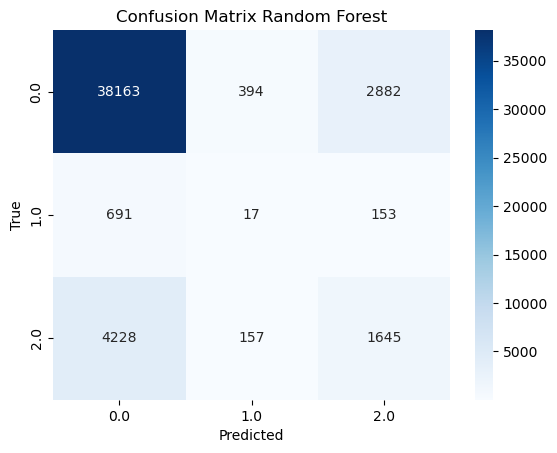

In [ ]:
# Evaluasi
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr"))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_final.classes_, yticklabels=rf_final.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

rf_all = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
rf_all.fit(X_train_res, y_train_res)

y_pred_all = rf_all.predict(X_test)
y_prob_all = rf_all.predict_proba(X_test)

acc_all = accuracy_score(y_test, y_pred_all)
f1_all = f1_score(y_test, y_pred_all, average="macro")
auc_all = roc_auc_score(y_test, y_prob_all, multi_class="ovr")

# === Model 2: Fitur Optimal (contoh: hasil RFE) ===
optimal_features = ['Age', 'BMI', 'GenHlth', 'HighBP', 'HighChol']
X_train_opt = X_train_res[optimal_features]
X_test_opt = X_test[optimal_features]

rf_opt = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
rf_opt.fit(X_train_opt, y_train_res)

y_pred_opt = rf_opt.predict(X_test_opt)
y_prob_opt = rf_opt.predict_proba(X_test_opt)

acc_opt = accuracy_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt, average="macro")
auc_opt = roc_auc_score(y_test, y_prob_opt, multi_class="ovr")

              Model  Accuracy  F1-score       AUC
0      All Features  0.841589  0.376062  0.699999
1  Optimal Features  0.824022  0.411341  0.688348


In [ ]:
df_compare = pd.DataFrame({
    "Model": ["All Features", "Optimal Features"],
    "Accuracy": [acc_all, acc_opt],
    "F1-score": [f1_all, f1_opt],
    "AUC": [auc_all, auc_opt]
})

print(df_compare)

              Model  Accuracy  F1-score       AUC
0      All Features  0.841589  0.376062  0.699999
1  Optimal Features  0.824022  0.411341  0.688348


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# parameter grid untuk Random Forest
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

# Random Forest base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,            # try 30 random combination
    cv=3,                 # 3-fold CV
    scoring='f1_macro',   # optimasi berdasarkan f1 macro
    random_state=42,
    n_jobs=-1,
    verbose=2
)

optimal_features = ['Age', 'BMI', 'GenHlth', 'HighBP', 'HighChol']
X_train_opt = X_train_res[optimal_features]
X_test_opt = X_test[optimal_features]

# fit RandomizedSearchCV
random_search.fit(X_train_opt, y_train_res)

# best parameters
print("Best Parameters:", random_search.best_params_)

# evaluasi data test
best_rf = random_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_opt)
y_prob_tuned = best_rf.predict_proba(X_test_opt)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average="macro")
auc_tuned = roc_auc_score(y_test, y_prob_tuned, multi_class="ovr")

print("\n=== Performance After Tuning ===")
print("Accuracy:", acc_tuned)
print("F1-score:", f1_tuned)
print("AUC:", auc_tuned)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  34.2s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  34.7s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  37.2s
[CV] END class_weight=balanced, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  34.3s
[CV] END class_weight=balanced, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  37.0s
[CV] END class_weight=balanced, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  36.1s
[CV] END class_weight=balanced, max_depth=5, max_features=None, mi